<a href="https://colab.research.google.com/github/Pumlisa97/mit805-airline-delays-pyspark/blob/MCMthethwa-Dev/notebooks/03_part2_mapreduce_and_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1. Storage Integration & Environment Setup
In this phase, we establish connection with our storage backend on Google Drive using `google.colab.drive` and configure our working directory containing the performance data. Keeping structured variables for file paths ensures our configuration is clear and maintainable.

In [2]:
from pathlib import Path

DATA_ROOT = Path("/content/drive/MyDrive/MIT805_Airline_Delays/data")

WORKING_DIR = DATA_ROOT / "working"

working_csvs = sorted(WORKING_DIR.glob("*.csv"))

In [4]:
subset_files = [
    str(f)
    for f in working_csvs
    if "_2024_" in f.name
]

In [5]:
!pip install -q pyspark


### 2. Distributed Engine Initialization
Here, we initialize a local Spark Session. The setting `.master("local[*]")` allocates all available CPU cores on our container runtime, enabling full multi-threaded processing for the execution of our tasks.

In [7]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("MIT805_Airline_Delays")
    .master("local[*]")
    .getOrCreate()
)

In [9]:
df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(subset_files)
)

### 3. Core Column Selection & Data Hygiene (Filter Phase)
To optimize our cluster's memory usage and avoid loading unnecessary columns, we define a list of `CORE_COLUMNS`. We then apply data cleaning filters (cleaning null delays and excluding cancelled flights) to ensure that the mathematical calculations in subsequent steps are performed on reliable, valid records.

In [10]:
CORE_COLUMNS = [
    "Year",
    "Quarter",
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "FlightDate",
    "Reporting_Airline",
    "DOT_ID_Reporting_Airline",
    "IATA_CODE_Reporting_Airline",
    "Flight_Number_Reporting_Airline",
    "Origin",
    "OriginCityName",
    "OriginState",
    "OriginStateName",
    "Dest",
    "DestCityName",
    "DestState",
    "DestStateName",
    "CRSDepTime",
    "DepTime",
    "DepDelay",
    "DepDelayMinutes",
    "DepDel15",
    "DepTimeBlk",
    "CRSArrTime",
    "ArrTime",
    "ArrDelay",
    "ArrDelayMinutes",
    "ArrDel15",
    "ArrTimeBlk",
    "Cancelled",
    "CancellationCode",
    "Diverted",
    "CRSElapsedTime",
    "ActualElapsedTime",
    "AirTime",
    "Distance",
    "DistanceGroup",
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
]

In [12]:
from pyspark.sql.functions import col

airline_df = df.select(*CORE_COLUMNS)

airline_df = airline_df.filter(
    col("Cancelled") == 0
)

airline_df = airline_df.filter(
    col("ArrDelay").isNotNull()
)

airline_df = airline_df.filter(
    col("DepDelay").isNotNull()
)

MAP Phase

### 4. Selection Map Phase
By reducing the schema only to the columns required for the aggregations (Airlines, Origins, Months, and Delay categories), we limit the serialization overhead across partition boundaries during the execution of our Spark job.

In [13]:
mapped_df = airline_df.select(
    "Reporting_Airline",
    "Origin",
    "Month",
    "ArrDelay",
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "LateAircraftDelay"
)

### 5. Distributed Aggregation 1 — Performance of Reporting Carriers
In this step, we aggregate average arrival delays grouped by airline. This operation triggers an internal shuffle phase across partitions to combine keys, revealing which carriers (such as `F9` and `AA`) suffer from the longest average delays.

In [15]:
from pyspark.sql.functions import avg

airline_delay = (
    mapped_df
    .groupBy("Reporting_Airline")
    .agg(
        avg("ArrDelay").alias("AverageArrivalDelay")
    )
)

top_airlines = (
    airline_delay
    .orderBy(
        "AverageArrivalDelay",
        ascending=False
    )
)

top_airlines.show(20, False)

+-----------------+-------------------+
|Reporting_Airline|AverageArrivalDelay|
+-----------------+-------------------+
|F9               |15.166218754047403 |
|AA               |13.409551936328976 |
|B6               |11.592470302478272 |
|NK               |7.393404579425906  |
|G4               |6.825077064517874  |
|OO               |6.616647584050251  |
|OH               |6.394536859741503  |
|HA               |6.194150838432806  |
|MQ               |5.297681429059265  |
|WN               |4.768096881901814  |
|AS               |4.010000572278814  |
|UA               |3.9676571049858955 |
|DL               |1.2535271745798062 |
|9E               |-0.4694345506519712|
|YX               |-5.764803572214157 |
+-----------------+-------------------+



### 6. Distributed Aggregation 2 — Monthly Temporal Trends
Grouping average delays by month allows us to observe macro temporal trends over the first four months of 2024. This highlights how systemic bottlenecks vary seasonally.

In [17]:
monthly_delay = (
    mapped_df
    .groupBy("Month")
    .agg(
        avg("ArrDelay").alias("AverageArrivalDelay")
    )
    .orderBy("Month")
)
monthly_delay.show()

+-----+-------------------+
|Month|AverageArrivalDelay|
+-----+-------------------+
|    1|   10.3522983801892|
|    2| 0.5934550690998294|
|    3|  6.504476326969165|
|    4| 5.3605435809434665|
+-----+-------------------+



### 7. Distributed Aggregation 3 — Root Cause Breakdown
By aggregating the sum of specific delay columns, we quantify the impact of individual delay causes. This directly compares operational factors (Carrier, Weather, NAS, and Late Aircraft).

In [19]:
from pyspark.sql.functions import sum

delay_causes = (
    mapped_df
    .agg(
        sum("CarrierDelay").alias("CarrierDelay"),
        sum("WeatherDelay").alias("WeatherDelay"),
        sum("NASDelay").alias("NASDelay"),
        sum("LateAircraftDelay").alias("LateAircraftDelay")
    )
)

delay_causes.show()

+------------+------------+---------+-----------------+
|CarrierDelay|WeatherDelay| NASDelay|LateAircraftDelay|
+------------+------------+---------+-----------------+
| 1.0269881E7|   2005903.0|6186439.0|       1.233986E7|
+------------+------------+---------+-----------------+



### 8. Understanding Spark Query Plans (Optimization & Execution DAG)
To verify how our transformations are distributed and optimized, we output the complete Spark query execution plans. Using `.explain(True)` breaks down the query compiling stages from the abstract parsed logical tree to the optimized physical stage showing pushed filters (`FileScan csv`), data distribution shuffling (`Exchange hashpartitioning`), and aggregation (`HashAggregate`).

In [20]:
top_airlines.explain(True)

== Parsed Logical Plan ==
'Sort ['AverageArrivalDelay DESC NULLS LAST], true
+- Aggregate [Reporting_Airline#23], [Reporting_Airline#23, avg(ArrDelay#59) AS AverageArrivalDelay#128]
   +- Project [Reporting_Airline#23, Origin#31, Month#19, ArrDelay#59, CarrierDelay#73, WeatherDelay#74, NASDelay#75, LateAircraftDelay#77]
      +- Filter isnotnull(DepDelay#48)
         +- Filter isnotnull(ArrDelay#59)
            +- Filter (Cancelled#64 = cast(0 as double))
               +- Project [Year#17, Quarter#18, Month#19, DayofMonth#20, DayOfWeek#21, FlightDate#22, Reporting_Airline#23, DOT_ID_Reporting_Airline#24, IATA_CODE_Reporting_Airline#25, Flight_Number_Reporting_Airline#27, Origin#31, OriginCityName#32, OriginState#33, OriginStateName#35, Dest#40, DestCityName#41, DestState#42, DestStateName#44, CRSDepTime#46, DepTime#47, DepDelay#48, DepDelayMinutes#49, DepDel15#50, DepTimeBlk#52, CRSArrTime#57, ... 18 more fields]
                  +- Relation [Year#17,Quarter#18,Month#19,DayofMonth#20

In [22]:
airport_delay = (
    mapped_df
    .groupBy("Origin")
    .agg(
        avg("ArrDelay").alias("AverageArrivalDelay")
    )
)

airport_delay.explain(True)

== Parsed Logical Plan ==
'Aggregate ['Origin], ['Origin, 'avg('ArrDelay) AS AverageArrivalDelay#238]
+- Project [Reporting_Airline#23, Origin#31, Month#19, ArrDelay#59, CarrierDelay#73, WeatherDelay#74, NASDelay#75, LateAircraftDelay#77]
   +- Filter isnotnull(DepDelay#48)
      +- Filter isnotnull(ArrDelay#59)
         +- Filter (Cancelled#64 = cast(0 as double))
            +- Project [Year#17, Quarter#18, Month#19, DayofMonth#20, DayOfWeek#21, FlightDate#22, Reporting_Airline#23, DOT_ID_Reporting_Airline#24, IATA_CODE_Reporting_Airline#25, Flight_Number_Reporting_Airline#27, Origin#31, OriginCityName#32, OriginState#33, OriginStateName#35, Dest#40, DestCityName#41, DestState#42, DestStateName#44, CRSDepTime#46, DepTime#47, DepDelay#48, DepDelayMinutes#49, DepDel15#50, DepTimeBlk#52, CRSArrTime#57, ... 18 more fields]
               +- Relation [Year#17,Quarter#18,Month#19,DayofMonth#20,DayOfWeek#21,FlightDate#22,Reporting_Airline#23,DOT_ID_Reporting_Airline#24,IATA_CODE_Reporting_A

### 9. Temporal Analysis - Micro-Patterns & Scheduled Dep Hours
To analyze performance trends during different times of day, we divide scheduled departure hours into 24 bins. We categorize delays using a 15-minute threshold to calculate a `late_rate` metric.

In [23]:
from pyspark.sql import functions as F

heatmap_df = (
    airline_df
    .filter(F.col("CRSDepTime").isNotNull())
    .withColumn(
        "ScheduledDepHour",
        F.floor(F.col("CRSDepTime") / 100).cast("int")
    )
)

In [24]:
heatmap_df.select(
    "CRSDepTime",
    "ScheduledDepHour"
).show(10)

+----------+----------------+
|CRSDepTime|ScheduledDepHour|
+----------+----------------+
|       856|               8|
|       856|               8|
|       856|               8|
|       856|               8|
|       856|               8|
|       856|               8|
|       856|               8|
|       856|               8|
|       856|               8|
|       856|               8|
+----------+----------------+
only showing top 10 rows


In [25]:
heatmap_df = (
    heatmap_df
    .withColumn(
        "CompletedArrival",
        F.when(
            (F.col("Cancelled") == 0) &
            (F.col("Diverted") == 0) &
            F.col("ArrDelay").isNotNull(),
            1
        ).otherwise(0)
    )
)

In [26]:
heatmap_df = (
    heatmap_df
    .withColumn(
        "LateCompletedArrival",
        F.when(
            (F.col("CompletedArrival") == 1) &
            (F.col("ArrDelay") >= 15),
            1
        ).otherwise(0)
    )
)

In [27]:
hourly_delay = (
    heatmap_df
    .groupBy("ScheduledDepHour")
    .agg(
        F.sum("CompletedArrival")
         .alias("completed_arrivals"),

        F.sum("LateCompletedArrival")
         .alias("late_completed_arrivals")
    )
)

In [28]:
hourly_delay = (
    heatmap_df
    .groupBy("ScheduledDepHour")
    .agg(
        F.sum("CompletedArrival")
         .alias("completed_arrivals"),

        F.sum("LateCompletedArrival")
         .alias("late_completed_arrivals")
    )
)

In [29]:
hourly_delay = (
    hourly_delay
    .withColumn(
        "late_rate",
        F.col("late_completed_arrivals") /
        F.col("completed_arrivals")
    )
    .orderBy("ScheduledDepHour")
)

### 10. Temporal Heatmap Visualization
This heatmap visualizes the hourly late arrival rates. The resulting gradient highlights a rising delay rate that peaks in the evening hours due to daily operational knock-on effects.

In [30]:
hourly_delay.show(24, False)

+----------------+------------------+-----------------------+-------------------+
|ScheduledDepHour|completed_arrivals|late_completed_arrivals|late_rate          |
+----------------+------------------+-----------------------+-------------------+
|0               |3516              |690                    |0.1962457337883959 |
|1               |1490              |345                    |0.23154362416107382|
|2               |622               |144                    |0.2315112540192926 |
|3               |451               |96                     |0.21286031042128603|
|4               |250               |57                     |0.228              |
|5               |61829             |6006                   |0.0971388830484077 |
|6               |158136            |16217                  |0.10255096878636111|
|7               |151455            |19468                  |0.1285398303126341 |
|8               |147382            |21010                  |0.14255472174349648|
|9              

In [ ]:
hourly_pd = hourly_delay.toPandas()

hourly_pd.head()

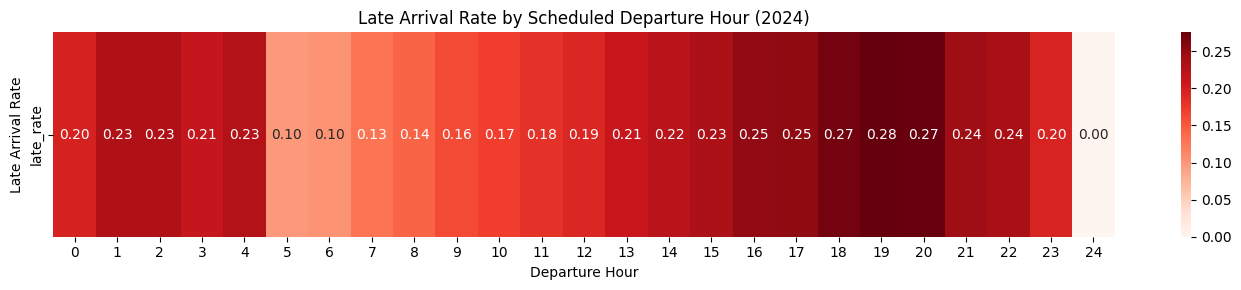

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure hourly_pd is defined
hourly_pd = hourly_delay.toPandas()

heatmap_data = (
    hourly_pd
    .set_index("ScheduledDepHour")
    [["late_rate"]]
    .T
)

plt.figure(figsize=(14,3))

sns.heatmap(
    heatmap_data,
    cmap="Reds",
    annot=True,
    fmt=".2f"
)

plt.title(
    "Late Arrival Rate by Scheduled Departure Hour (2024)"
)

plt.xlabel("Departure Hour")
plt.ylabel("Late Arrival Rate")

plt.tight_layout()
plt.show()

### 11. Coarse-Grained Departure Period Analysis
By grouping the hours into structured periods ('Early Morning', 'Midday', 'Evening'), we summarize our detailed findings into clear operational blocks to verify our temporal hypotheses.

In [33]:
heatmap_df = (
    heatmap_df
    .withColumn(
        "DeparturePeriod",
        F.when(
            (F.col("ScheduledDepHour") >= 5) &
            (F.col("ScheduledDepHour") <= 9),
            "Early Morning"
        )
        .when(
            (F.col("ScheduledDepHour") >= 10) &
            (F.col("ScheduledDepHour") <= 15),
            "Midday"
        )
        .when(
            (F.col("ScheduledDepHour") >= 16) &
            (F.col("ScheduledDepHour") <= 22),
            "Evening"
        )
        .otherwise("Other")
    )
)

In [35]:
period_results = (
    heatmap_df
    .filter(F.col("DeparturePeriod") != "Other")
    .groupBy("DeparturePeriod")
    .agg(
        F.sum("CompletedArrival").alias("Completed"),
        F.sum("LateCompletedArrival").alias("Late")
    )
    .withColumn(
        "LateRate",
        F.col("Late") /
        F.col("Completed")
    )
)

period_results.show(truncate=False)

+---------------+---------+------+-------------------+
|DeparturePeriod|Completed|Late  |LateRate           |
+---------------+---------+------+-------------------+
|Evening        |744177   |193432|0.25992740974257467|
|Early Morning  |641534   |82411 |0.1284592866473172 |
|Midday         |793893   |159926|0.20144528292855587|
+---------------+---------+------+-------------------+



### 12. Interfacing SQL Views in Spark
We create a temporary relational view (`vw_mapped_flights`) to demonstrate Spark SQL's hybrid compatibility, letting us execute standard ANSI SQL queries over distributed DataFrames.

In [36]:
from pyspark.sql import functions as F

mapped_df = airline_df.select(
    "Reporting_Airline",
    "Origin",
    "Month",
    "ArrDelay",
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "LateAircraftDelay"
)

mapped_df.createOrReplaceTempView(
    "vw_mapped_flights"
)

In [37]:
spark.sql("""
SELECT *
FROM vw_mapped_flights
LIMIT 10
""").show()

+-----------------+------+-----+--------+------------+------------+--------+-----------------+
|Reporting_Airline|Origin|Month|ArrDelay|CarrierDelay|WeatherDelay|NASDelay|LateAircraftDelay|
+-----------------+------+-----+--------+------------+------------+--------+-----------------+
|               9E|   LGA|    1|   -11.0|        NULL|        NULL|    NULL|             NULL|
|               9E|   LGA|    1|   -28.0|        NULL|        NULL|    NULL|             NULL|
|               9E|   LGA|    1|   -25.0|        NULL|        NULL|    NULL|             NULL|
|               9E|   LGA|    1|    27.0|         0.0|         0.0|     4.0|             23.0|
|               9E|   LGA|    1|     2.0|        NULL|        NULL|    NULL|             NULL|
|               9E|   LGA|    1|    10.0|        NULL|        NULL|    NULL|             NULL|
|               9E|   LGA|    1|    31.0|        27.0|         0.0|     4.0|              0.0|
|               9E|   LGA|    1|    -9.0|        N

### 13. Plotting Performance Metrics
The following visualizations (carrier performance, monthly trends, and delay causes) convert our aggregated, distributed outputs into clear visual insights.

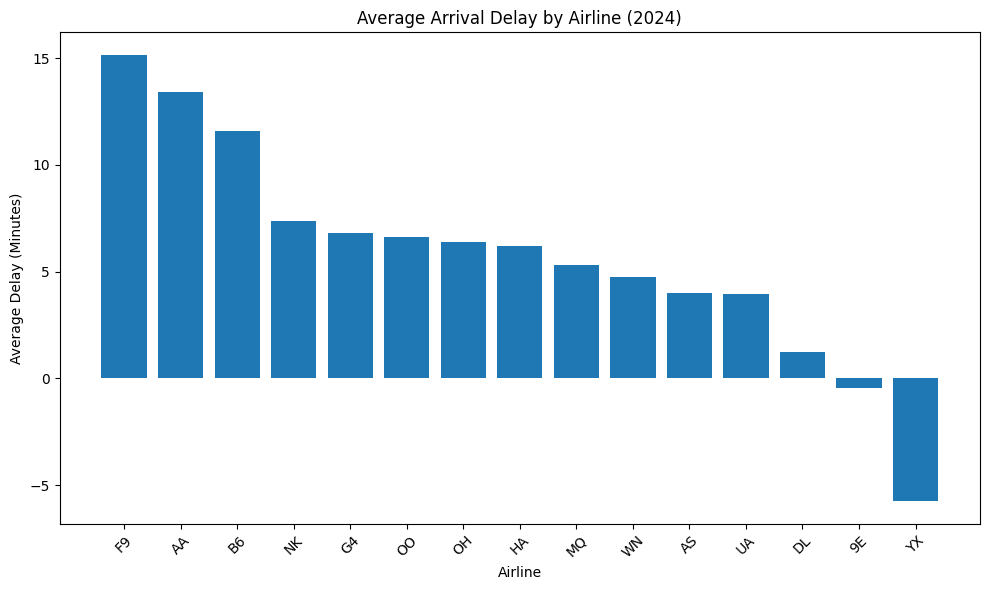

In [38]:
airlines_pd = (
    top_airlines
    .limit(20)
    .toPandas()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    airlines_pd["Reporting_Airline"],
    airlines_pd["AverageArrivalDelay"]
)

plt.title("Average Arrival Delay by Airline (2024)")
plt.xlabel("Airline")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

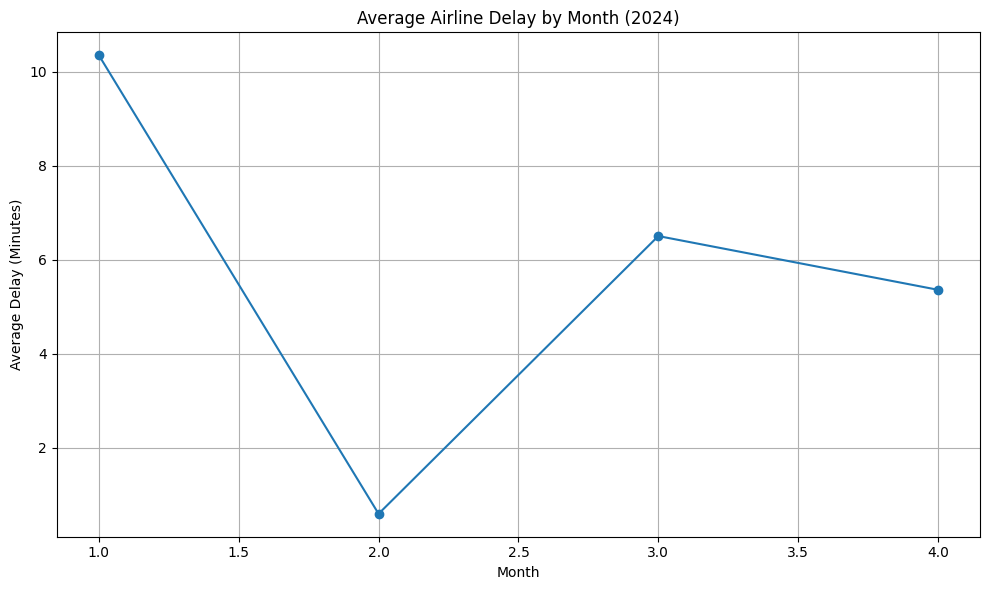

In [39]:
monthly_pd = monthly_delay.toPandas()

plt.figure(figsize=(10,6))

plt.plot(
    monthly_pd["Month"],
    monthly_pd["AverageArrivalDelay"],
    marker="o"
)

plt.title("Average Airline Delay by Month (2024)")
plt.xlabel("Month")
plt.ylabel("Average Delay (Minutes)")
plt.grid(True)

plt.tight_layout()
plt.show()

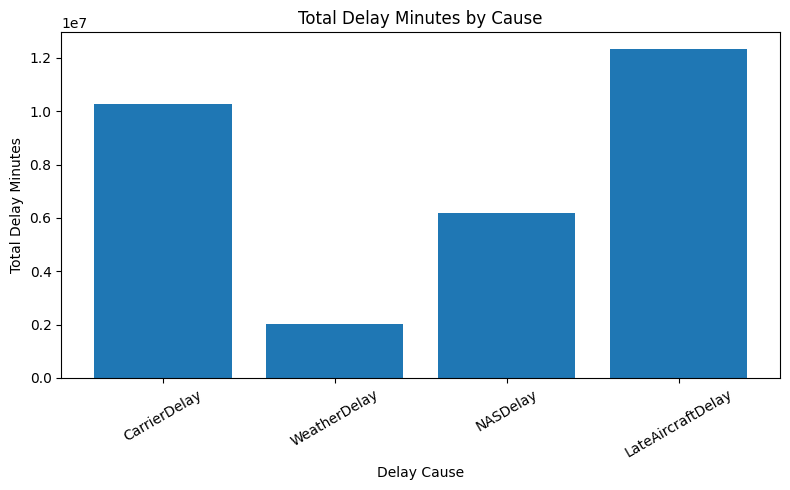

In [40]:
causes_pd = delay_causes.toPandas()

causes = causes_pd.iloc[0]

plt.figure(figsize=(8,5))

plt.bar(
    causes.index,
    causes.values
)

plt.title("Total Delay Minutes by Cause")
plt.xlabel("Delay Cause")
plt.ylabel("Total Delay Minutes")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### 14. Persisting Artifacts & Execution Logs
To document this distributed execution, we write our configuration metadata, row counts, and physical execution plans directly to persistent text files on Google Drive for submission.

In [41]:
airport_delay.explain(True)

== Parsed Logical Plan ==
'Aggregate ['Origin], ['Origin, 'avg('ArrDelay) AS AverageArrivalDelay#238]
+- Project [Reporting_Airline#23, Origin#31, Month#19, ArrDelay#59, CarrierDelay#73, WeatherDelay#74, NASDelay#75, LateAircraftDelay#77]
   +- Filter isnotnull(DepDelay#48)
      +- Filter isnotnull(ArrDelay#59)
         +- Filter (Cancelled#64 = cast(0 as double))
            +- Project [Year#17, Quarter#18, Month#19, DayofMonth#20, DayOfWeek#21, FlightDate#22, Reporting_Airline#23, DOT_ID_Reporting_Airline#24, IATA_CODE_Reporting_Airline#25, Flight_Number_Reporting_Airline#27, Origin#31, OriginCityName#32, OriginState#33, OriginStateName#35, Dest#40, DestCityName#41, DestState#42, DestStateName#44, CRSDepTime#46, DepTime#47, DepDelay#48, DepDelayMinutes#49, DepDel15#50, DepTimeBlk#52, CRSArrTime#57, ... 18 more fields]
               +- Relation [Year#17,Quarter#18,Month#19,DayofMonth#20,DayOfWeek#21,FlightDate#22,Reporting_Airline#23,DOT_ID_Reporting_Airline#24,IATA_CODE_Reporting_A

In [42]:
top_airlines.explain(True)

== Parsed Logical Plan ==
'Sort ['AverageArrivalDelay DESC NULLS LAST], true
+- Aggregate [Reporting_Airline#23], [Reporting_Airline#23, avg(ArrDelay#59) AS AverageArrivalDelay#128]
   +- Project [Reporting_Airline#23, Origin#31, Month#19, ArrDelay#59, CarrierDelay#73, WeatherDelay#74, NASDelay#75, LateAircraftDelay#77]
      +- Filter isnotnull(DepDelay#48)
         +- Filter isnotnull(ArrDelay#59)
            +- Filter (Cancelled#64 = cast(0 as double))
               +- Project [Year#17, Quarter#18, Month#19, DayofMonth#20, DayOfWeek#21, FlightDate#22, Reporting_Airline#23, DOT_ID_Reporting_Airline#24, IATA_CODE_Reporting_Airline#25, Flight_Number_Reporting_Airline#27, Origin#31, OriginCityName#32, OriginState#33, OriginStateName#35, Dest#40, DestCityName#41, DestState#42, DestStateName#44, CRSDepTime#46, DepTime#47, DepDelay#48, DepDelayMinutes#49, DepDel15#50, DepTimeBlk#52, CRSArrTime#57, ... 18 more fields]
                  +- Relation [Year#17,Quarter#18,Month#19,DayofMonth#20

In [43]:
from pathlib import Path
from datetime import datetime

OUTPUT_DIR = DATA_ROOT.parent / "output" / "part2" / "execution_evidence"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

summary_text = f"""
MIT 805 Part 2 — Spark Execution Evidence
Generated: {datetime.now().isoformat()}

Spark application ID: {spark.sparkContext.applicationId}
Spark version: {spark.version}
Spark UI URL reported by Spark: {spark.sparkContext.uiWebUrl}
Configured spark.sql.shuffle.partitions: {spark.conf.get('spark.sql.shuffle.partitions')}

Input validation
----------------
Selected CSV files: {len(subset_files)}

Action executed
---------------
top_airlines.show()

Output
------
Rows loaded: {df.count():,}
Rows after cleaning: {airline_df.count():,}

Top-level analyses completed:
- Airline delay analysis
- Airport delay analysis
- Monthly trend analysis
- Delay cause analysis

Physical-plan evidence
----------------------
The Spark execution plans were generated using:

top_airlines.explain(True)
airport_delay.explain(True)

Key confirmed operators:
- FileScan csv
- Filter
- Project
- HashAggregate
- Exchange hashpartitioning
- Sort
- AdaptiveSparkPlan

Interpretation
--------------
The Exchange hashpartitioning operator indicates a shuffle stage where
records were redistributed across partitions before aggregation.
The HashAggregate operator performed distributed aggregation to calculate
average delays and summary statistics. These operations demonstrate
MapReduce-style processing within Spark's DAG execution model.
"""

with open(
    OUTPUT_DIR / "spark_execution_summary.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(summary_text)

print("Saved:",
      OUTPUT_DIR / "spark_execution_summary.txt")

Saved: /content/drive/MyDrive/MIT805_Airline_Delays/output/part2/execution_evidence/spark_execution_summary.txt


In [44]:
import io
import sys

buffer = io.StringIO()

old_stdout = sys.stdout
sys.stdout = buffer

top_airlines.explain(True)

sys.stdout = old_stdout

with open(
    OUTPUT_DIR / "airline_physical_plan.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(buffer.getvalue())

print("Saved airline plan.")

Saved airline plan.


In [45]:
buffer = io.StringIO()

old_stdout = sys.stdout
sys.stdout = buffer

airport_delay.explain(True)

sys.stdout = old_stdout

with open(
    OUTPUT_DIR / "airport_physical_plan.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(buffer.getvalue())

print("Saved airport plan.")

Saved airport plan.


In [46]:
for file in OUTPUT_DIR.iterdir():
    print(file.name)

spark_execution_summary.txt
airline_physical_plan.txt
airport_physical_plan.txt
